In [4]:
print('Radha!')

Radha!


In [5]:
# ============================================================
# 1. SETUP & ENVIRONMENT VARIABLES
# ============================================================

# Un-comment to install dependencies if needed:
# !pip install langgraph langchain-openai langchain-core

import os
from typing import TypedDict, List
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

# Set your API Key (or ensure it's in your environment)
# os.environ["OPENAI_API_KEY"] = "your-api-key-here"

True

In [6]:
# ============================================================
# 2. STATE DEFINITION
# ============================================================

class IncidentState(TypedDict):
    incident_data: str
    analysis: str
    investigation_steps: List[str]
    final_report: str

In [7]:
# ============================================================
# 3. INITIALIZE MODEL
# ============================================================

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [8]:
# ============================================================
# 4. DEFINE NODES
# ============================================================

def analyze_incident_node(state: IncidentState):
    """Analyze the raw incident log/alert."""
    prompt = f"Analyze the following incident alert and extract core symptoms: {state['incident_data']}"
    response = llm.invoke([HumanMessage(content=prompt)])
    return {"analysis": response.content}

def investigate_node(state: IncidentState):
    """Investigate root causes based on analysis."""
    prompt = f"Given this incident analysis: '{state['analysis']}', list 3 potential root causes or investigation steps."
    response = llm.invoke([HumanMessage(content=prompt)])
    steps = [s.strip() for s in response.content.split("\n") if s.strip()]
    return {"investigation_steps": steps}

def generate_report_node(state: IncidentState):
    """Generate the final report summary."""
    prompt = f"""
    Create a concise incident resolution report based on:
    Analysis: {state['analysis']}
    Investigation Findings: {state['investigation_steps']}
    
    Provide actionable steps for the engineering team.
    """
    response = llm.invoke([HumanMessage(content=prompt)])
    return {"final_report": response.content}

In [9]:
# ============================================================
# 5. TEST DATA
# ============================================================

sample_incident = (
    "CRITICAL ALERT: API Gateway returning 500 status codes. "
    "PostgreSQL connection timeout after 30000ms."
)

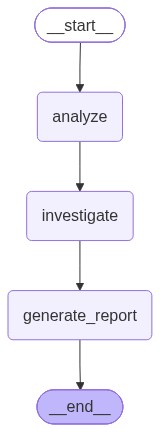

In [10]:
# ============================================================
# 6. GRAPH BUILD
# ============================================================

builder = StateGraph(IncidentState)

# Add nodes
builder.add_node("analyze", analyze_incident_node)
builder.add_node("investigate", investigate_node)
builder.add_node("generate_report", generate_report_node)

# Add edges
builder.add_edge(START, "analyze")
builder.add_edge("analyze", "investigate")
builder.add_edge("investigate", "generate_report")
builder.add_edge("generate_report", END)

# Compile graph
app = builder.compile()
app

In [11]:
# ============================================================
# 7. PART 1 - GRAPH NODE UPDATES STREAMING
# ============================================================

print("=== PART 1: LangGraph Node Workflow Progress Streaming ===\n")

# stream_mode="updates" yields updates from each node as it completes
for event in app.stream({"incident_data": sample_incident}, stream_mode="updates"):
    for node_name, state_update in event.items():
        print(f"✅ [Completed Node: {node_name}]")
        for key, value in state_update.items():
            print(f"   ↳ {key}: {value}\n")

=== PART 1: LangGraph Node Workflow Progress Streaming ===

✅ [Completed Node: analyze]
   ↳ analysis: Based on the incident alert provided, the core symptoms can be extracted as follows:

1. **API Gateway Issue**: The API Gateway is returning 500 status codes, indicating an internal server error. This suggests that there is a problem with the server processing the requests.

2. **Database Connection Problem**: There is a PostgreSQL connection timeout occurring after 30,000 milliseconds (30 seconds). This indicates that the application is unable to establish a connection to the PostgreSQL database within the expected time frame.

In summary, the core symptoms are:
- API Gateway returning 500 status codes (internal server error).
- PostgreSQL connection timeout after 30 seconds.

✅ [Completed Node: investigate]
   ↳ investigation_steps: ['Based on the incident analysis provided, here are three potential root causes or investigation steps to consider:', '1. **Server Resource Exhaustion**

In [12]:
# ============================================================
# 8. PART 2 - PURE LLM TOKEN STREAMING
# ============================================================

print("=== PART 2: Pure LLM Token Streaming ===\n")

prompt = f"Summarize immediate actions for: {sample_incident}"

# Stream individual tokens as they are generated by the model
for chunk in llm.stream([HumanMessage(content=prompt)]):
    print(chunk.content, end="", flush=True)
print("\n")

=== PART 2: Pure LLM Token Streaming ===

Immediate actions to address the CRITICAL ALERT regarding the API Gateway returning 500 status codes and PostgreSQL connection timeouts:

1. **Check API Gateway Logs**: Review the logs for any error messages or stack traces that could indicate the root cause of the 500 status codes.

2. **Inspect PostgreSQL Connection Settings**: Verify the database connection settings, including timeout configurations, to ensure they are correctly set.

3. **Monitor Database Performance**: Check the PostgreSQL server for performance issues, such as high load, slow queries, or resource constraints.

4. **Increase Connection Timeout**: If necessary, consider temporarily increasing the connection timeout to see if it alleviates the issue while investigating further.

5. **Test Database Connectivity**: Run tests to confirm that the API Gateway can successfully connect to the PostgreSQL database.

6. **Review Recent Changes**: Identify any recent changes to the API

In [13]:
# ============================================================
# 9. PART 3 - COMBINED GRAPH & LLM TOKEN STREAMING
# ============================================================

print("=== PART 3: Combined LangGraph Token & Node Streaming ===\n")

# stream_mode="messages" streams individual message tokens generated inside graph nodes
for msg, metadata in app.stream({"incident_data": sample_incident}, stream_mode="messages"):
    # Output token chunks generated during the 'generate_report' node
    if metadata.get("langgraph_node") == "generate_report" and msg.content:
        print(msg.content, end="", flush=True)

print("\n\n=== Incident Assistant Workflow Complete ===")

=== PART 3: Combined LangGraph Token & Node Streaming ===

### Incident Resolution Report

**Incident Summary:**
- **Date/Time of Incident:** [Insert Date/Time]
- **Reported Symptoms:**
  - API Gateway returning 500 status codes (internal server error).
  - PostgreSQL connection timeout after 30 seconds.

---

**Investigation Findings:**
1. **Server Resource Exhaustion:**
   - **Action:** Check server resource utilization (CPU, memory, disk I/O) to assess if the server is under heavy load. If resource exhaustion is detected, consider scaling resources or optimizing current workloads.

2. **Database Configuration or Performance Issues:**
   - **Action:** Review PostgreSQL configuration settings, focusing on connection limits and timeout settings. Investigate for long-running queries or locks that may be causing timeouts. Check database logs for errors or warnings that could indicate underlying issues.

3. **Network Connectivity Problems:**
   - **Action:** Examine network connectivity b